Importing necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Union, Tuple
import pandas as pd
from scipy.optimize import curve_fit

## **Question 1**

Defining functions for solving ODEs

In [2]:
Scalar = Union[float, np.ndarray]

# Verlet
def verlet(
  f,
  x: float,
  yn: float,
  ynm1: float,
  h: float,
) -> float:
  """
  Advance one step using the Verlet position update.

  Parameters:
    f: Callable acceleration function f(x, y).
    x: Current x value.
    yn: Current position y_n.
    ynm1: Previous position y_{n-1}.
    h: Step size.

  Returns:
    Estimated position y_{n+1}.
  """
  return 2*yn - ynm1 + f(x, yn)*(h**2)

# Velocity Verlet
def velocity_verlet(
  f,
  x: float,
  yn: float,
  vn: float,
  h: float,
) -> Tuple[float, float]:
  """
  Advance one step using the velocity Verlet method.

  Parameters:
    f: Callable acceleration function f(x, y).
    x: Current x value.
    yn: Current position y_n.
    vn: Current velocity v_n.
    h: Step size.

  Returns:
    Tuple (y_{n+1}, v_{n+1}) for the next position and velocity.
  """
  ynp1 = yn + vn*h + f(x, yn)*0.5*(h**2)
  vnp1 = vn + h*(f(x, yn) + f(x + h, ynp1))/2
  return ynp1, vnp1

# RK4
def rk4(
    f,
    x: float,
    y: Scalar,
    h: float,
) -> Scalar:
    """
    Advance one step using classical fourth-order Runge-Kutta.

    Parameters:
      f: Callable derivative function f(x, y).
      x: Current x value.
      y: Current y value (can be scalar or array-like).
      h: Step size.

    Returns:
      Estimated y value at x + h.
    """
    k1 = f(x, y)
    k2 = f(x + h/2, y + h*k1/2)
    k3 = f(x + h/2, y + h*k2/2)
    k4 = f(x + h, y + h*k3)

    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6

# Caller function for verlet
def caller_v(
  f,
  xs: np.ndarray,
  y0: Scalar,
  v0: Scalar,
  N: int,
  h: float,
) -> np.ndarray:
  """
  Generate positions using Verlet, given initial position and velocity.

  Parameters:
    f: Callable acceleration function f(x, y).
    xs: Array of x values to step through.
    y0: Initial position.
    v0: Initial velocity.
    N: Number of steps/points to compute.
    h: Step size.

  Returns:
    Array of positions y with length N.
  """
  ys = np.zeros(N)
  x0 = xs[0]
  ys[0] = y0

  # This is given
  ys[1] = y0 + v0*h + 0.5*f(x0, y0)*(h**2)

  for i in range(2, N):
    x = xs[i-1]
    ys[i] = verlet(f, x, ys[i-1], ys[i-2], h)

  return ys

# Caller function for velocity verlet and leapfrog
def caller_vvl(
  f,
  xs: np.ndarray,
  y0: np.ndarray,
  v0: np.ndarray,
  N: int,
  h: float,
  method
) -> Tuple[np.ndarray, np.ndarray]:
  """
  Generate positions and velocities using a two-variable one-step method.

  Parameters:
    f: Callable acceleration function f(x, y).
    xs: Array of x values to step through.
    y0: Initial position.
    v0: Initial velocity.
    N: Number of steps/points to compute.
    h: Step size.
    method: One-step method with signature method(f, x, y, v, h).

  Returns:
    Tuple (ys, vs) of positions and velocities, each length N.
  """
  ys = np.zeros((N, len(y0)))
  vs = np.zeros((N, len(v0)))
  ys[0, :] = y0
  vs[0, :] = v0

  for i in range(1, N):
    x = xs[i-1]
    ys[i, :], vs[i, :] = method(f, x, ys[i-1, :], vs[i-1, :], h)

  return ys, vs

# Caller for RK4 and Euler
def caller_rk4e(
    f,
    xs: np.ndarray,
    y0: np.ndarray,
    N: int,
    h: float,
    method
) -> np.ndarray:
    """
    Generate solution values by repeatedly applying RK4/Euler method.

    Parameters:
      f: Callable derivative function f(x, y).
      xs: Array of x values to step through.
      y0: Initial y value (array-like).
      N: Number of steps/points to compute.
      h: Step size.
      method: The method to be used.

    Returns:
      Array of y values with shape (N, len(y0)).
    """
    y = y0
    ys = np.zeros((N, len(y0)))

    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(f, x, y, h)
    
    return ys

Given the equations:

$y = y[0] - position$

$p = y[1] - momentum$

 $\frac{d}{dt} \begin{pmatrix} y[0] \\ y[1] \end{pmatrix} = \begin{pmatrix} y[1] \\ -4\pi^2y[0] \end{pmatrix}$

Defining parameters and functions

In [3]:
# Defining parameters
h = 0.01
ti, tf = 0, 15
y0v, p0v = 1.0, 0.0     # Initial conditions for Verlet
y0vv, p0vv = np.array([1.0]), np.array([0.0])   # Initial conditions for Velocity Verlet
y0s = np.array([1.0, 0.0])

# Calculating N and xs
N = int((tf - ti)/h) + 1
ts = ti + h*np.arange(N)

# Defining aceeleration function
def a(t, y):
  return -4*(np.pi**2)*y

# Defining f(x) for RK4 method
def f1(t, y):
  return np.asarray([y[1], -4*(np.pi**2)*y[0]])

**Part (a)**

The equations for position and momentum after solving analytically are:

$y = \cos(2\pi t)$

$p = -2\pi\sin(2\pi t)$.

In [4]:
def exact(t):
  return np.asarray([np.cos(2*np.pi*t), -2*np.pi*np.sin(2*np.pi*t)]).T

ys_exact = exact(ts)       # Exact Solution
ysv = caller_v(a, ts, y0v, p0v, N, h)     # Verlet
ysvv, psvv = caller_vvl(a, ts, y0vv, p0vv, N, h, velocity_verlet)       # Velocity Verlet
ysr = caller_rk4e(f1, ts, y0s, N, h, rk4)     # RK4

Plotting the solutions

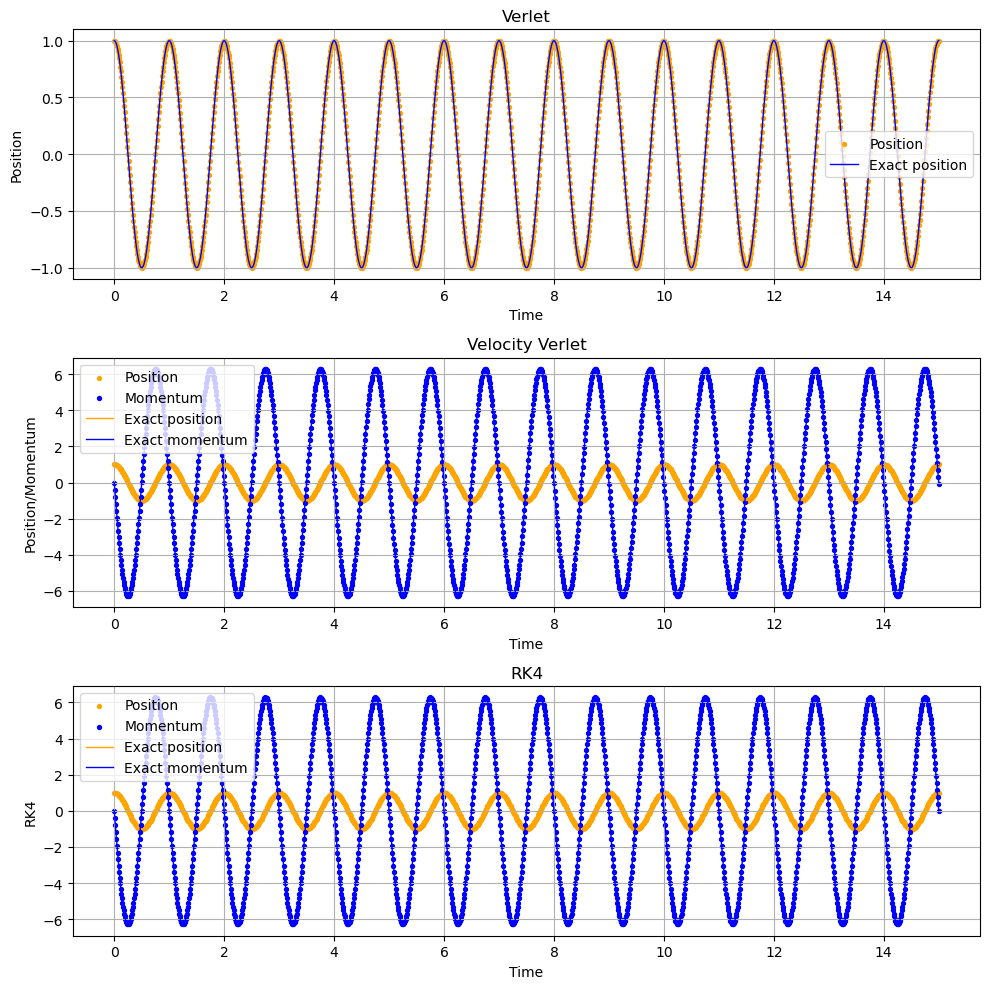

In [5]:
plt.figure(figsize=(10, 10))
methodnames_1 = ["Verlet", "Velocity Verlet", "RK4"]

# Verlet
plt.subplot(3, 1, 1)
plt.scatter(ts, ysv, s = 8, color = "orange", label = "Position")
plt.plot(ts, ys_exact[:, 0], linewidth = 1, color = "blue", label = "Exact position")

plt.xlabel("Time")
plt.ylabel("Position")
plt.legend()
plt.title(methodnames_1[0])
plt.grid()


# Velocity Verlet
plt.subplot(3, 1, 2)
plt.scatter(ts, ysvv, s = 8, color = "orange", label = "Position")
plt.scatter(ts, psvv, s = 8, color = "blue", label = "Momentum")
plt.plot(ts, ys_exact[:, 0], linewidth = 1, color = "orange", label = "Exact position")
plt.plot(ts, ys_exact[:, 1], linewidth = 1, color = "blue", label = "Exact momentum")

plt.xlabel("Time")
plt.ylabel("Position/Momentum")
plt.legend()
plt.title(methodnames_1[1])
plt.grid()


# RK4
plt.subplot(3, 1, 3)
plt.scatter(ts, ysr[:, 0], s = 8, color = "orange", label = "Position")
plt.scatter(ts, ysr[:, 1], s = 8, color = "blue", label = "Momentum")
plt.plot(ts, ys_exact[:, 0], linewidth = 1, color = "orange", label = "Exact position")
plt.plot(ts, ys_exact[:, 1], linewidth = 1, color = "blue", label = "Exact momentum")

plt.title("RK4")
plt.grid()
plt.xlabel("Time")
plt.ylabel(methodnames_1[2])
plt.legend()

plt.tight_layout()
plt.show()

**Part (b)**

Defining Parameters

In [6]:
# Parameters
ni, nf = -4, -2
step = 0.2
methods_1 = [verlet, velocity_verlet, rk4]

# Array for h values, errors and final position points
hs = 10.0 ** np.arange(ni, nf + step, step)
errors = np.zeros((len(hs), len(methods_1)))

# Exact final position
yf_exact = exact(tf)[0]     

Calculating final position and errors

In [7]:
for i in range(len(hs)):
    h = hs[i]
    N = int((tf - ti)/h) + 1
    ts = ti + h*np.arange(N)

    # Calculating final value of position
    yfv = caller_v(a, ts, y0v, p0v, N, h)[-1]    # Verlet
    ysvv, psvv = caller_vvl(a, ts, y0vv, p0vv, N, h, velocity_verlet)   # Velocity Verlet
    yfvv = ysvv[-1]
    yfrk4 = caller_rk4e(f1, ts, y0s, N, h, rk4)[-1, 0]    # RK4

    # Calculating errors
    errors[i, 0] = abs(yf_exact - yfv)   # Verlet
    errors[i, 1] = abs(yf_exact - yfvv)  # Velocity Verlet
    errors[i, 2] = abs(yf_exact - yfrk4) # RK4

C:\Users\ARYA BASAK\AppData\Local\Temp\ipykernel_15620\4182038499.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  errors[i, 1] = abs(yf_exact - yfvv)  # Velocity Verlet


Viewing data in pandas Dataframe

In [8]:
data_pf = np.column_stack((hs, errors))
col_names = ["h"] + methodnames_1
df = pd.DataFrame(data_pf, columns = col_names)
df

,h,Verlet,Velocity Verlet,RK4
0,0.000100,1.258704e-11,1.222911e-12,3.774758e-15
1,0.000158,1.771628e-07,1.771681e-07,1.794938e-07
2,0.000251,5.996714e-09,5.996022e-09,7.115049e-09
3,0.000398,2.570606e-07,2.570592e-07,2.749787e-07
4,0.000631,1.148632e-06,1.148633e-06,1.244083e-06
5,0.001000,1.877714e-05,1.877714e-05,1.973916e-05
6,0.001585,5.111034e-06,5.111034e-06,6.431967e-06
7,0.002512,3.707244e-05,3.707244e-05,4.597405e-05
8,0.003981,1.673658e-04,1.673658e-04,2.153411e-04
9,0.006310,2.663421e-05,2.663421e-05,9.081811e-05


**Part (c)**

Fitting and plotting log error with log h

**Convergence Orders:**

- **Verlet:** slope close to 2 $\Rightarrow$ $\log(\text{error}) = 2\log(h)$ $\Rightarrow$ error $\propto h^2$

- **Velocity Verlet:** slope close to 2 $\Rightarrow$ $\log(\text{error}) = 2\log(h)$ $\Rightarrow$ error $\propto h^2$

- **RK4:** slope close to 4 $\Rightarrow$ $\log(\text{error}) = 4\log(h)$ $\Rightarrow$ error $\propto h^4$

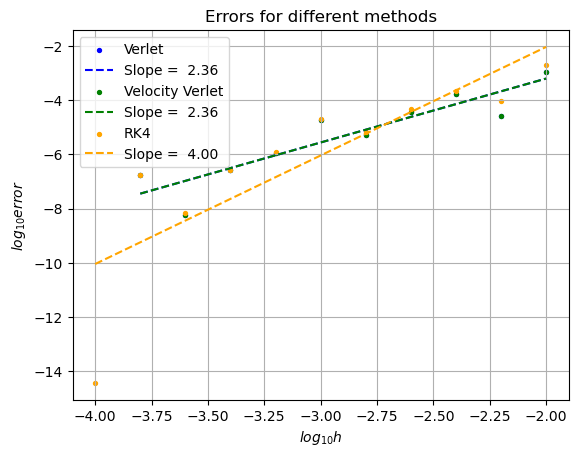

In [9]:
def eqn_of_line(x, m, c):
    return m*x + c

colors = ["blue", "green", "orange"]
log_errors = np.log10(errors)
log_hs = np.log10(hs)

for i in range(len(methods_1)):
    # Smaller h values are dominated by errors betond what can be measured by the computer
    if i in (0, 1):    
        start = 1
    else:
        start = 0

    log_hs_method = log_hs[start:]
    log_error_method = log_errors[start:, i]

    # Fitting the errors with a straight line
    popt, pcov = curve_fit(eqn_of_line, log_hs_method, log_error_method)
    slope, intercept = popt
    
    # Plotting the errors
    plt.scatter(log_hs_method, log_error_method, s = 8, color = colors[i], label = methodnames_1[i])
    plt.plot(log_hs_method, eqn_of_line(log_hs_method, slope, intercept), '--', color = colors[i], label = f"Slope = {slope: 0.2f}")

plt.xlabel("$log_{10} h$")
plt.ylabel("$log_{10} error$")
plt.title("Errors for different methods")
plt.legend()
plt.grid()
plt.show()

## **Question 2**

***Part (a)***

### Forces Acting on the Projectile

Two forces act on the mass:

1. **Gravitational force**
$$
\mathbf{F}_g = (0, -mg)
$$

2. **Linear drag force**
$$
\mathbf{F}_d = -\gamma \mathbf{v}
$$
where $\mathbf{v} = (v_x, v_y)$.

---

### Equations from Newton’s Second Law

Using Newton’s second law,

$$
m \frac{d\mathbf{v}}{dt} = \mathbf{F}_g + \mathbf{F}_d,
$$

we obtain the component-wise equations:

$$
m \frac{dv_x}{dt} = -\gamma v_x
$$

$$
m \frac{dv_y}{dt} = -mg - \gamma v_y
$$

Dividing by $m$,

$$
\frac{dv_x}{dt} = -\frac{\gamma}{m} v_x
$$

$$
\frac{dv_y}{dt} = -g - \frac{\gamma}{m} v_y
$$

---

### First-Order System of Equations

Introducing position variables, the equations of motion become:

$$
\frac{dx}{dt} = v_x
$$

$$
\frac{dy}{dt} = v_y
$$

$$
\frac{dv_x}{dt} = -\frac{\gamma}{m} v_x
$$

$$
\frac{dv_y}{dt} = -g - \frac{\gamma}{m} v_y
$$

This system of first-order differential equations is suitable for numerical solution using Euler, Velocity Verlet, and RK4 methods.

---

### Initial Conditions

The initial velocity components are

$$
v_x(0) = v_0 \cos 60^\circ = 5 \,\text{m s}^{-1}
$$

$$
v_y(0) = v_0 \sin 60^\circ = 5\sqrt{3} \,\text{m s}^{-1}
$$

and the initial position is

$$
x(0) = 0, \qquad y(0) = 0.
$$


***Part (b)***

The equations of motion obtained in part (a) are

$$
\frac{dx}{dt} = v_x,
$$

$$
\frac{dy}{dt} = v_y,
$$

$$
\frac{dv_x}{dt} = -\frac{\gamma}{m} v_x,
$$

$$
\frac{dv_y}{dt} = -g - \frac{\gamma}{m} v_y.
$$

These form a system of four coupled first-order differential equations.  
We define the state vector as

$$
\mathbf{Y}(t) =
\begin{pmatrix}
x \\
y \\
v_x \\
v_y
\end{pmatrix}.
$$

The system can then be written compactly as

$$
\frac{d\mathbf{Y}}{dt} =
\begin{pmatrix}
v_x \\
v_y \\
-\frac{\gamma}{m} v_x \\
- g - \frac{\gamma}{m} v_y
\end{pmatrix}.
$$

---

### Initial Conditions

The projectile starts from the origin,

$$
x(0)=0, \qquad y(0)=0,
$$

with initial velocity components

$$
v_x(0)=v_0 \cos 60^\circ,
$$

$$
v_y(0)=v_0 \sin 60^\circ.
$$

---

### Numerical Procedure

The trajectory is obtained by integrating the equations using:

- Euler method,
- Velocity Verlet method,
- Fourth-order Runge–Kutta (RK4) method.

The integration is continued until the projectile reaches the ground, i.e.

$$
y(t) \le 0.
$$

The resulting trajectory is obtained by plotting $y$ versus $x$ for each method.


Defining constants

In [10]:
# Constants
m = 2.0
g = 9.8
gamma0 = 2.0
u0 = 10.0
theta = np.deg2rad(60)

# Initial velocities
vx0 = u0*np.cos(theta)
vy0 = u0*np.sin(theta)

# Initial state vector
Y0 = np.array([0.0, 0.0, vx0, vy0])

Defining functions for applying methods

In [11]:
# RHS function for Euler and RK4
def rhs(t, Y, gamma):
    x, y, vx, vy = Y
    return np.array([
        vx,
        vy,
        -(gamma/m)*vx,
        -g - (gamma/m)*vy
    ])

# Acceleration function for Velocity-Verlet
def accel(t, r, v, gamma):
    ax = -(gamma/m)*v[0]
    ay = -g - (gamma/m)*v[1]
    return np.array([ax, ay])

# Velocity-Verlet in vector form
def velocity_verlet_vector(f, t: float, rn: np.ndarray, vn: np.ndarray, h, gamma: float) -> Tuple[np.ndarray, np.ndarray]:
    """
    Calculate the next position and velocity using the velocity Verlet method for vector quantities.

    Parameters:
        f: Callable acceleration function f(t, r, v).
        t: Current time.
        rn: Current position vector.
        vn: Current velocity vector.

    Returns:
        Tuple (r_{n+1}, v_{n+1}) for the next position and velocity vectors.
    """
    an = f(t, rn, vn, gamma)   # Current acceleration

    rnp1 = rn + vn*h + 0.5*an*h**2
    v_half = vn + 0.5*h*an
    anp1 = f(t+h, rnp1, v_half, gamma)   # velocity dependence handled below
    vnp1 = vn + 0.5*h*(an + anp1)

    return rnp1, vnp1

# Euler
def euler_vector(f, x: float, y: np.ndarray, h: float, gamma: float) -> np.ndarray:
    """
    Advance one step using Euler's method.

    Parameters:
      f: Callable derivative function f(x, y).
      x: Current x value.
      y: Current y value (array-like).
      h: Step size.
      gamma: Velocity-dependent drag coefficient.

    Returns:
      Estimated y value at x + h.
    """
    return y + h*f(x, y, gamma)

# RK4
def rk4_vector(
    f,
    x: float,
    y: np.ndarray,
    h: float,
    gamma: float
) -> np.ndarray:
    """
    Advance one step using classical fourth-order Runge-Kutta.

    Parameters:
      f: Callable derivative function f(x, y).
      x: Current x value.
      y: Current y value (array-like).
      h: Step size.
      gamma = Velocity-dependent drag coefficient.

    Returns:
      Estimated y value at x + h.
    """
    k1 = f(x, y, gamma)
    k2 = f(x + h/2, y + h*k1/2, gamma)
    k3 = f(x + h/2, y + h*k2/2, gamma)
    k4 = f(x + h, y + h*k3, gamma)

    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6

Defining Parameters for all methods

In [12]:
t0 = 0  # Initial time
N = 200    # No. of steps
h = 1e-2  # Step size

# Initial values for velocity verlet
y0 = np.array([0.0, 0.0])
v0 = np.array([vx0, vy0])

# T = 2.0    # Final time, if known beforehand
# ts = np.linspace(0, T, N)   # Time grid, if final time is known
# h = ts[1] - ts[0]   # h value

Implementing the methods

In [ ]:
Ye, Yrk4, yvv, vvv = Y0.copy(), Y0.copy(), y0.copy(), v0.copy()
t = t0

# Arrays to store the values
ysE = np.zeros((N, len(y0)))
ysrk4 = np.zeros((N, len(y0)))
ysvv = np.zeros((N, len(y0)))
i = 0

# Loop continues till projectile is above the ground and we have not exceeded the maximum number of steps
while Ye[1] >= 0 and i < N:
    # Storing the values
    ysE[i, :] = Ye[:2]   # Only position components are needed for the next step
    ysrk4[i, :] = Yrk4[:2]
    ysvv[i, :] = yvv[:2]

    Ye = euler_vector(rhs, t, Ye, h, gamma0)   # Euler
    Yrk4 = rk4_vector(rhs, t, Yrk4, h, gamma0) # RK4
    yvv, vvv = velocity_verlet_vector(accel, t, yvv, vvv, h, gamma0)    # Velocity Verlet

    # Updating variables
    t += h
    i += 1

# These can be used when the final time T is known
# YsE = caller_rk4e(rhs, ts, Y0, N, h, euler)    # Euler
# ysVV, vsVV = caller_vvl(accel, ts, y0, v0, N, h, velocity_verlet_vector)  # Velocity Verlet
# YsRK4 = caller_rk4e(rhs, ts, Y0, N, h, rk4)     # RK4

[5.         8.66025404]
[5.         8.66025404]


Plotting the solutions of the different methods

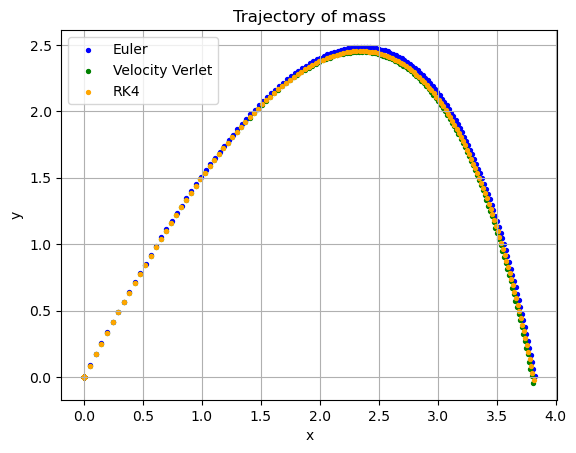

In [27]:
plt.scatter(ysE[:, 0], ysE[:, 1], s = 8, color = "blue", label = "Euler")
plt.scatter(ysvv[:, 0], ysvv[:, 1], s = 8, color = "green", label = "Velocity Verlet")
plt.scatter(ysrk4[:, 0], ysrk4[:, 1], s = 8, color = "orange", label = "RK4")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajectory of mass")
plt.grid()
plt.legend()
plt.show()

**Part (c)**

Calculating trajectories for different gamma values

Through a tuple containing the values of different methods for each gamma

In [ ]:
# Defining parameters
gammai, gammaf = 0, 10
step = 1
gammas = np.arange(gammai, gammaf + step, step)
N = 200
h = 1e-2

# Array to store the trajectories for different gamma values
gammas_data = []

# Calculating trajectories for different gamma values
for i in range(len(gammas)):
    gamma = gammas[i]
    j = 0
    t = t0
    Ye, Yrk4, yvv, vvv = Y0, Y0, y0, v0     # Resetting the state vectors
    print(Y0)

    # Arrays to store the values
    ysE = np.zeros((N, len(y0)))
    ysrk4 = np.zeros((N, len(y0)))
    ysvv = np.zeros((N, len(y0)))

    # Loop continues till projectile is above the ground and we have not exceeded the maximum number of steps
    while Ye[1] >= 0 and j < N:
        # Storing the values
        ysE[j, :] = Ye[:2]  # Euler
        ysrk4[j, :] = Yrk4[:2]  # RK4
        ysvv[j, :] = yvv[:2]    # Velocity Verlet

        # Updating the state vectors
        Ye = euler_vector(rhs, t, Ye, h, gamma)   # Euler
        Yrk4 = rk4_vector(rhs, t, Yrk4, h, gamma) # RK4
        yvv, vvv = velocity_verlet_vector(accel, t, yvv, vvv, h, gamma)    # Velocity Verlet

        # Updating variables
        t += h
        j += 1
    
    print(Y0)
    gammas_data.append((ysE.copy(), ysrk4.copy(), ysvv.copy()))   # Storing the data for this gamma value



plt.figure(figsize=(10, 50))

for i in range(len(gammas)):
    data = gammas_data[i]
    
    plt.subplot(11, 1, i+1)
    plt.scatter(data[0][:, 0], data[0][:, 1], s = 8, color = "blue", label = "Euler")
    plt.scatter(data[1][:, 0], data[1][:, 1], s = 8, color = "green", label = "Velocity Verlet")
    plt.scatter(data[2][:, 0], data[2][:, 1], s = 8, color = "orange", label = "RK4")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Trajectory of mass for gamma = {gammas[i]}")
    plt.grid()
    plt.legend()

plt.tight_layout()
plt.show()

Through 3D array

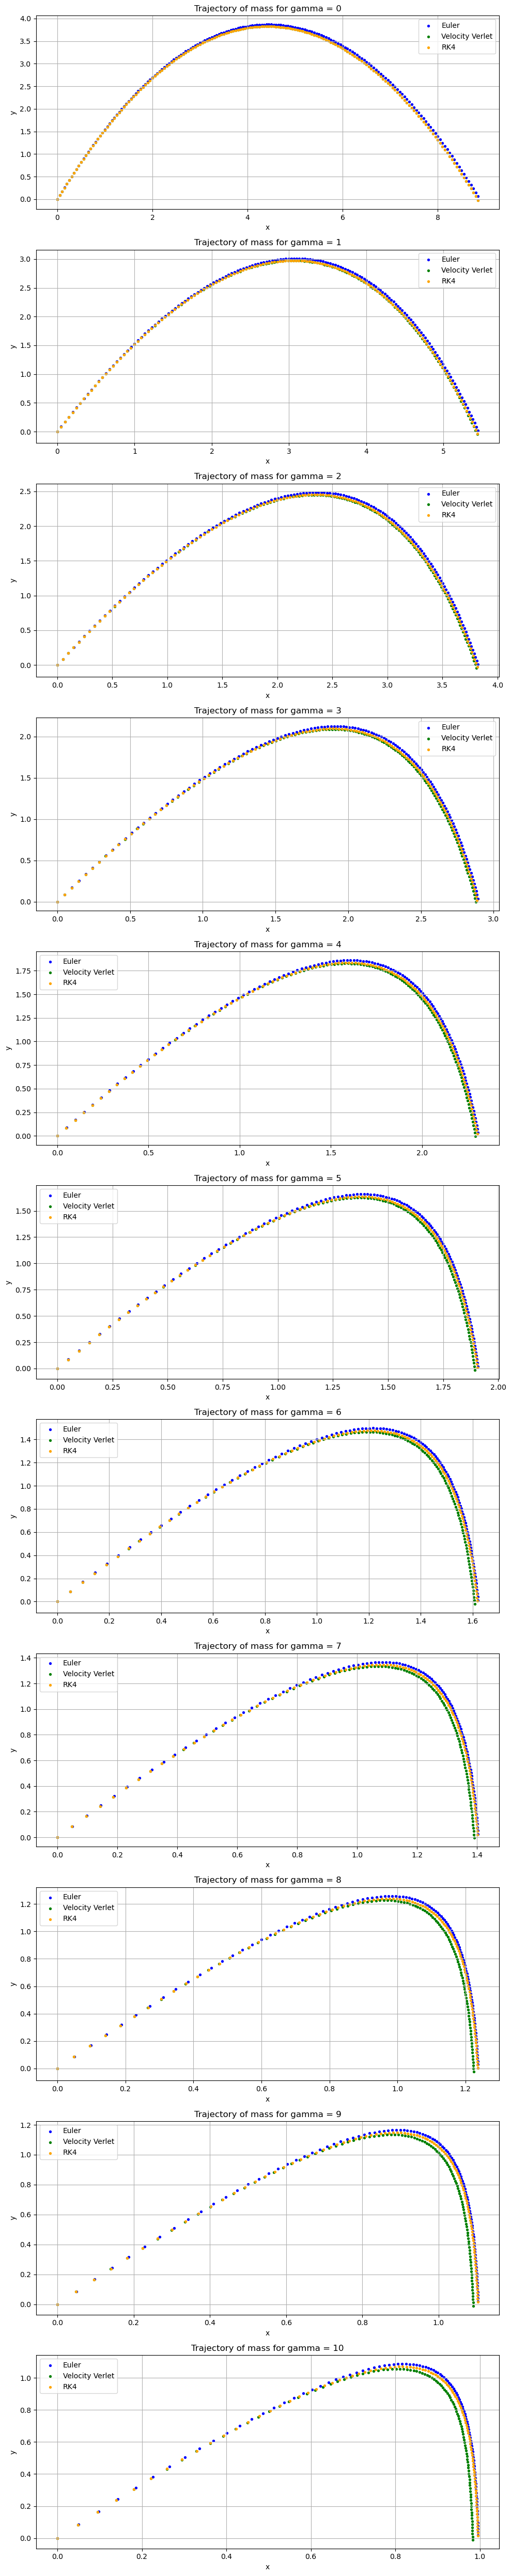

In [33]:
# Defining parameters
gammai, gammaf = 0, 10
step = 1
gammas = np.arange(gammai, gammaf + step, step)
N = 200
h = 1e-2

# Arrays to store the values
ysE = np.zeros((N, len(y0), len(gammas)))
ysrk4 = np.zeros((N, len(y0), len(gammas)))
ysvv = np.zeros((N, len(y0), len(gammas)))
stop_indices = np.zeros((len(gammas)), dtype=int)

# Calculating trajectories for different gamma values
for i in range(len(gammas)):
    gamma = gammas[i]
    j = 0
    t = t0
    Ye, Yrk4, yvv, vvv = Y0.copy(), Y0.copy(), y0.copy(), v0.copy()     # Resetting the state vectors

    # Loop continues till projectile is above the ground and we have not exceeded the maximum number of steps
    while Ye[1] >= 0 and j < N:
        # Storing the values
        ysE[j, :, i] = Ye[:2]  # Euler
        ysrk4[j, :, i] = Yrk4[:2]  # RK4
        ysvv[j, :, i] = yvv[:2]    # Velocity Verlet

        # Updating the state vectors
        Ye = euler_vector(rhs, t, Ye, h, gamma)   # Euler
        Yrk4 = rk4_vector(rhs, t, Yrk4, h, gamma) # RK4
        yvv, vvv = velocity_verlet_vector(accel, t, yvv, vvv, h, gamma)    # Velocity Verlet

        # Updating variables
        t += h
        j += 1

    stop_indices[i] = j

plt.figure(figsize=(10, 50))

for i in range(len(gammas)):
    stop = stop_indices[i]    
    plt.subplot(11, 1, i+1)

    plt.scatter(ysE[:stop, 0, i], ysE[:stop, 1, i], s = 8, color = "blue", label = "Euler")
    plt.scatter(ysvv[:stop, 0, i], ysvv[:stop, 1, i], s = 8, color = "green", label = "Velocity Verlet")
    plt.scatter(ysrk4[:stop, 0, i], ysrk4[:stop, 1, i], s = 8, color = "orange", label = "RK4")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Trajectory of mass for gamma = {gammas[i]}")
    plt.grid()
    plt.legend()

plt.tight_layout()
plt.show()

Plotting trajectories for different gammas

Plotting trajectories for different methods

NameError: name 'gammas_data' is not defined

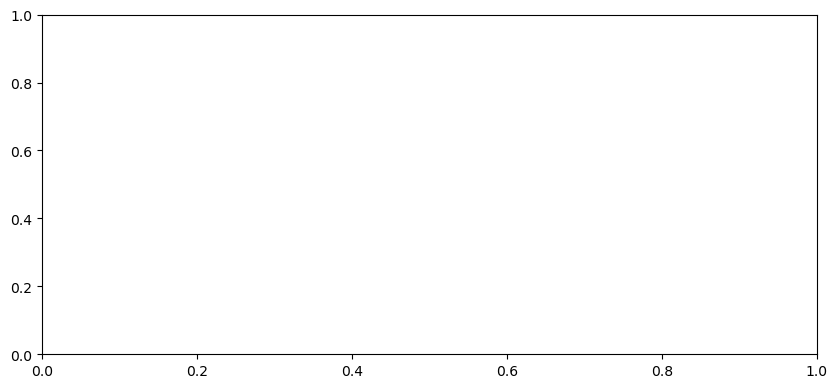

In [17]:
plt.figure(figsize=(10, 15))

# Euler
plt.subplot(3, 1, 1)
for i in range(len(gammas)):
    data = gammas_data[i]
    ysE = data[0]
    plt.scatter(ysE[:, 0], ysE[:, 1], s = 8, label = f"Gamma = {gammas[i]}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler")
plt.grid()
plt.legend()

# Velocity Verlet
plt.subplot(3, 1, 2)
for i in range(len(gammas)):
    data = gammas_data[i]
    ysvv = data[1]
    plt.scatter(ysvv[:, 0], ysvv[:, 1], s = 8, label = f"Gamma = {gammas[i]}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Velocity Verlet")
plt.grid()
plt.legend()

# RK4
plt.subplot(3, 1, 3)
for i in range(len(gammas)):
    data = gammas_data[i]
    ysrk4 = data[2]
    plt.scatter(ysrk4[:, 0], ysrk4[:, 1], s = 8, label = f"Gamma = {gammas[i]}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("RK4")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

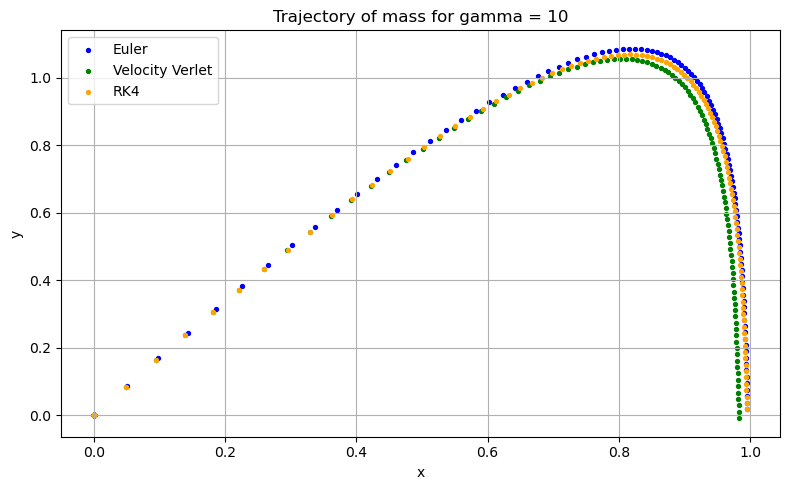

In [35]:
# Defining parameters
gamma = 10
N = 150
h = 1e-2

# Calculating trajectories gamma = 10
gamma = gammas[i]
j = 0
t = t0
Ye, Yrk4, yvv, vvv = Y0.copy(), Y0.copy(), y0.copy(), v0.copy()     # Resetting the state vectors

# Arrays to store the values
ysE = np.zeros((N, len(y0)))
ysrk4 = np.zeros((N, len(y0)))
ysvv = np.zeros((N, len(y0)))

# Loop continues till projectile is above the ground and we have not exceeded the maximum number of steps
while Ye[1] >= 0 and j < N:
    # Storing the values
    ysE[j, :] = Ye[:2]  # Euler
    ysrk4[j, :] = Yrk4[:2]  # RK4
    ysvv[j, :] = yvv[:2]    # Velocity Verlet

    # Updating the state vectors
    Ye = euler_vector(rhs, t, Ye, h, gamma)   # Euler
    Yrk4 = rk4_vector(rhs, t, Yrk4, h, gamma) # RK4
    yvv, vvv = velocity_verlet_vector(accel, t, yvv, vvv, h, gamma)    # Velocity Verlet

    # Updating variables
    t += h
    j += 1



plt.figure(figsize=(8, 5))

plt.scatter(ysE[:, 0], ysE[:, 1], s = 8, color = "blue", label = "Euler")
plt.scatter(ysvv[:, 0], ysvv[:, 1], s = 8, color = "green", label = "Velocity Verlet")
plt.scatter(ysrk4[:, 0], ysrk4[:, 1], s = 8, color = "orange", label = "RK4")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Trajectory of mass for gamma = {gammas[i]}")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
df = pd.DataFrame(np.column_stack((ysE[:, 1], ysvv[:, 1], ysrk4[:])), columns=[""])